### Домашнее задание по визуализации

В домашнем задании будем работать с данными фильмов на IMDB. 

Для начала считаем данные и проигнорируем все строки, которые не распарсились (для простоты).

In [1]:
import pandas as pd
import seaborn as sns
df = pd.read_csv('imdb.csv', on_bad_lines='skip')

/home/ddstu/Topaz2090/shad_env/lib/python3.13/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde


__Задача 1:__ С каким параметром больше всего коррелирует число побед? 
Ответ на задачу - название колонки в dataframe, с которой больше всего коррелирует `nrOfWins`.

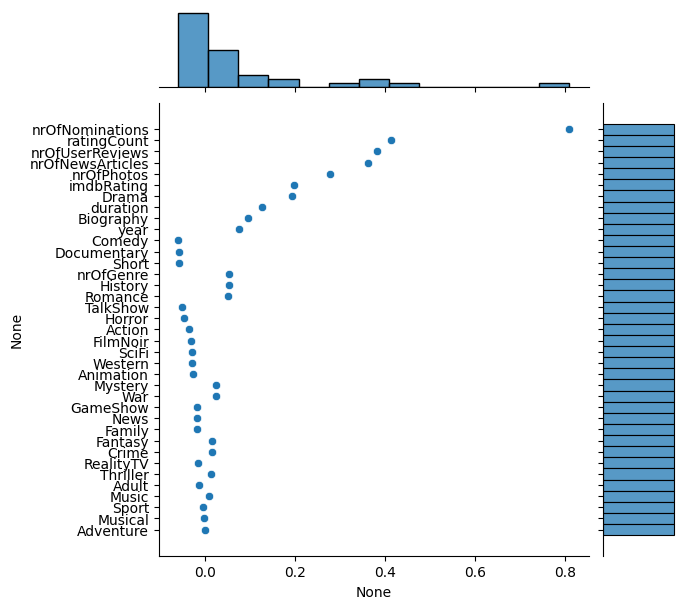

In [44]:
correlations = df.corr(numeric_only = True)['nrOfWins'].drop('nrOfWins')
correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).index)
sns.jointplot(y=correlations.index, x=correlations.values,
    palette=['red' if x < 0 else 'green' for x in correlations.values])

__Задача 2:__ Посмотрите, как изменялась средняя оценка фильмов (рейтинг IMDB) с течением времени? В какое десятилетие была самая высокая средняя оценка. 

Ответ - tuple, где на первом месте тип тренда (слово 'ascending' или 'descending'), на втором - десятилие, например, если самые "хорошие" фильмы были в период 1950 - 1959, то 1950.

In [13]:
print(min(df['year']))
max(df['year'])

1888.0


2017.0

In [26]:
import copy
tmp = copy.copy(df)
tmp['year']

0        1921.0
1        1925.0
2        1927.0
3        1926.0
4        1931.0
          ...  
14327    2005.0
14328    1957.0
14329    1996.0
14330    2002.0
14331    2003.0
Name: year, Length: 14332, dtype: float64

In [43]:
df[((1990 <= df['year']) & (df['year'] < 2000))]

,fn,tid,title,wordsInTitle,url,imdbRating,ratingCount,duration,year,type,...,News,RealityTV,Romance,SciFi,Short,Sport,TalkShow,Thriller,War,Western
125,titles01/tt0099685,tt0099685,GoodFellas - Drei Jahrzehnte in der Mafia (1990),goodfellas drei jahrzehnte in der mafia,http://www.imdb.com/title/tt0099685/,8.8,515242.0,8760.0,1990.0,video.movie,...,0,0,0,0,0,0,0,0,0,0
126,titles01/tt0101414,tt0101414,Die Schöne und das Biest (1991),die sch ne und das biest,http://www.imdb.com/title/tt0101414/,8.1,208331.0,5040.0,1991.0,video.movie,...,0,0,0,0,0,0,0,0,0,0
127,titles01/tt0102926,tt0102926,Das Schweigen der Lämmer (1991),das schweigen der l mmer,http://www.imdb.com/title/tt0102926/,8.6,584102.0,7080.0,1991.0,video.movie,...,0,0,0,0,0,0,0,1,0,0
128,titles01/tt0103064,tt0103064,Terminator 2 - Tag der Abrechnung (1991),terminator tag der abrechnung,http://www.imdb.com/title/tt0103064/,8.5,523543.0,8220.0,1991.0,video.movie,...,0,0,0,1,0,0,0,1,0,0
129,titles01/tt0105236,tt0105236,Reservoir Dogs - Wilde Hunde (1992),reservoir dogs wilde hunde,http://www.imdb.com/title/tt0105236/,8.4,454684.0,5940.0,1992.0,video.movie,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14319,titles04/index.html.9975,tt0657309,Die Nanny That's Midlife (TV Episode 1996),die nanny that s midlife tv episode,http://www.imdb.com/title/tt0657309/,7.3,49.0,1800.0,1996.0,video.episode,...,0,0,0,0,0,0,0,0,0,0
14320,titles04/index.html.9976,tt0657336,Die Nanny The Honeymoon's Overboard (TV Episod...,die nanny the honeymoon s overboard tv episode,http://www.imdb.com/title/tt0657336/,7.4,56.0,1800.0,1998.0,video.episode,...,0,0,0,0,0,0,0,0,0,0
14321,titles04/index.html.9977,tt0657347,Die Nanny The Party's Over (TV Episode 1995),die nanny the party s over tv episode,http://www.imdb.com/title/tt0657347/,7.4,56.0,1800.0,1995.0,video.episode,...,0,0,0,0,0,0,0,0,0,0
14326,titles04/index.html.9987,tt0669703,Parker Lewis - Der Coole von der Schule Parker...,parker lewis der coole von der schule parker l...,http://www.imdb.com/title/tt0669703/,7.6,16.0,1800.0,1991.0,video.episode,...,0,0,0,0,0,0,0,0,0,0


In [32]:
bins = [i - 1 for i in range(1880, 2020, 10)]
labels = [str(i - 10) + ' : ' + str(i - 1) for i in range(1890, 2020, 10)]

tmp['year_m'] = pd.cut(tmp['year'], bins=bins, labels=labels)
tmp.groupby('year_m').agg({'imdbRating': 'mean', 'fn': 'count'})

/tmp/ipykernel_1048/3773665275.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby('year_m').agg({'imdbRating': 'mean', 'fn': 'count'})


,imdbRating,fn
year_m,,
1880 : 1889,7.500000,2
1890 : 1899,6.333333,3
1900 : 1909,6.980000,5
1910 : 1919,6.780000,58
1920 : 1929,7.525325,158
1930 : 1939,7.257602,347
1940 : 1949,7.174375,484
1950 : 1959,6.972546,669
1960 : 1969,7.109625,820


__Задача 3:__ Исследумем распределение оценок фильмов по жанрам (если фильм принадлежит нескольким жанрам, то будем учитывать его в каждом из них). Для простоты будем смотреть на топ-10 самых популярных жанров (по числу фильмов с этим жанром). В ответе укажите 2 жанра: жанр с самой высокой средней оценкой (по медиане) и с самой большой дисперсией (по IQR). Если у нескольких жанров одинаковый показатель, то стоит указать первый по алфавиту. 

Ответ - tuple с двумя жанрами

In [ ]:
all_g = ('Action,Adult,Adventure,Animation,Biography,Comedy,Crime,' +
'Documentary,Drama,Family,Fantasy,FilmNoir,GameShow,History,Horror,Music,Musical,' +
'Mystery,News,RealityTV,Romance,SciFi,Short,Sport,TalkShow,Thriller,War,Western')

In [58]:
all_g = all_g.split(',')

In [61]:
ganars = [(i, df[i].sum(axis=0)) for i in all_g]

In [69]:
ganars.sort(key = lambda q:q[1], reverse=True)
ganars = ganars[:10]

In [ ]:
for g,_ in ganars:
    print(g, df[df[g]==1]['imdbRating'].median())

Drama 7.2
Comedy 7.0
Action 6.7
Crime 7.0
Romance 7.0
Adventure 6.9
Thriller 6.7
Documentary 7.3
Family 6.9
Horror 6.2


In [75]:
sorted('fha')

['a', 'f', 'h']

In [74]:
for g,_ in ganars:
    print(g, df[df[g]==1]['imdbRating'].quantile(0.75) -  df[df[g]==1]['imdbRating'].quantile(0.25))

Drama 1.1000000000000005
Comedy 1.3999999999999995
Action 1.4000000000000004
Crime 1.1999999999999993
Romance 1.2999999999999998
Adventure 1.2999999999999998
Thriller 1.2999999999999998
Documentary 1.0750000000000002
Family 1.5
Horror 1.5


__Задача 4:__ Посмотрим на распределение фильмов по числу слов в названии. Какой график вы бы для этого построили и какова мода (самое частотое значение) этого распределения?

Ответ - число слов, которое встречается в большем количестве фильмов.

In [90]:
df1 = copy.deepcopy(df)

df1['cw'] = df1['title'].apply(lambda x : len(x.strip().split()))
df1.groupby('cw').agg({'title': 'count'}).sort_values('title')

,title
cw,
21,1
22,2
20,3
1,5
19,7
18,8
17,13
16,14
15,34


__Вопрос 5:__ Посмотрим на то, как менялась со временем продолжительность фильмов? Постройте график и ответьте на вопрос, в каком десятилетии доля коротких фильмов (короче часа) была выше всего? Рассматриваем период >= 1920 года.

Ответ - десятилетие, например, если больше всего коротких фильмов было в период 1950 - 1959, то 1950.

<Axes: xlabel='year'>

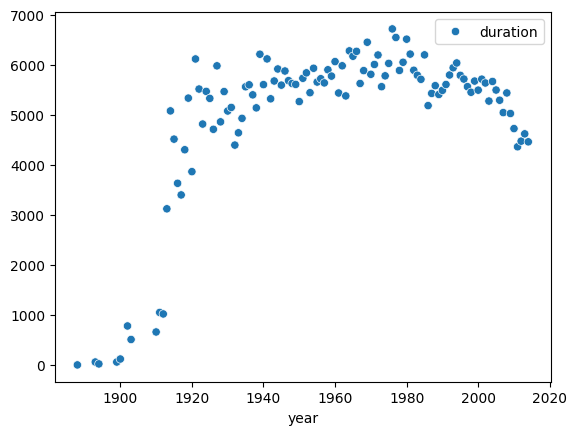

In [95]:
sns.scatterplot(df.groupby('year').agg({'duration':'mean'}))

In [111]:
def short(cl):
    return sum(cl < 60 * 60)/len(cl)

bins = [0] + [i - 1 for i in range(1930, 2030, 10)]
labels = [str(i - 10) + ' : ' + str(i - 1) for i in range(1930, 2030, 10)]

tmp = copy.deepcopy(df)
tmp['year_m'] = pd.cut(tmp[tmp['year'] >= 1920]['year'], bins=bins, labels=labels)
tmp.groupby('year_m').agg({'duration': short}).sort_values('duration')

/tmp/ipykernel_1048/1541327414.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby('year_m').agg({'duration': short}).sort_values('duration')


,duration
year_m,
1940 : 1949,0.061983
1950 : 1959,0.071749
1930 : 1939,0.095101
1920 : 1929,0.101266
1970 : 1979,0.104663
1980 : 1989,0.140886
1960 : 1969,0.145122
1990 : 1999,0.181202
2000 : 2009,0.203199


__Вопрос 6:__ И последний вопрос: фильмам какого жанра пользователи оставляют больше всего рецензий? Подумайте о  том, по какой метрике лучше всего смотреть. В ответе укажите жанр.

In [120]:
a = [(i, df[df[i]==1]['ratingCount'].median()) for i in all_g]
a.sort(key = lambda x:x[1], reverse=True)
a

[('Thriller', np.float64(19135.5)),
 ('Mystery', np.float64(10550.0)),
 ('Sport', np.float64(9715.5)),
 ('Action', np.float64(9369.5)),
 ('Crime', np.float64(9036.0)),
 ('Fantasy', np.float64(8754.5)),
 ('Adventure', np.float64(7787.0)),
 ('Horror', np.float64(7510.5)),
 ('SciFi', np.float64(6525.0)),
 ('Biography', np.float64(6055.0)),
 ('Romance', np.float64(6009.0)),
 ('Drama', np.float64(5651.0)),
 ('Comedy', np.float64(4214.0)),
 ('History', np.float64(3561.5)),
 ('War', np.float64(3490.0)),
 ('Animation', np.float64(3197.0)),
 ('Family', np.float64(3096.0)),
 ('Music', np.float64(3086.0)),
 ('FilmNoir', np.float64(2260.0)),
 ('Western', np.float64(2008.0)),
 ('Musical', np.float64(1892.5)),
 ('RealityTV', np.float64(1164.5)),
 ('GameShow', np.float64(192.0)),
 ('Documentary', np.float64(117.5)),
 ('News', np.float64(110.0)),
 ('Short', np.float64(108.0)),
 ('Adult', np.float64(86.0)),
 ('TalkShow', np.float64(67.0))]